# 한국 비교

데이터를 분석했을 때 우리의 가장 큰 목적은 다른나라들을 기반으로 한국의 데이터들을 중점적으로 진행하는게 좋을것같다고 생각합니다.
데이터를 분석해서 원인을 찾고 그 원인을 해결하므로서
행복지수를 높이는 방안으로 구성했습니다.

In [58]:
# 한국어 출력 위함
%%capture
!pip install koreanize-matplotlib
import koreanize_matplotlib

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv('/content/drive/MyDrive/mid/WHR_2018_2022.csv')
df.head()

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,year
0,Finland,Western Europe,7.632,1.305,1.592,0.874,0.681,0.202,0.393,2018
1,Norway,Western Europe,7.594,1.456,1.582,0.861,0.686,0.286,0.340,2018
2,Denmark,Western Europe,7.555,1.351,1.590,0.868,0.683,0.284,0.408,2018
3,Iceland,Western Europe,7.495,1.343,1.644,0.914,0.677,0.353,0.138,2018
4,Switzerland,Western Europe,7.487,1.420,1.549,0.927,0.660,0.256,0.357,2018


In [61]:
# 각 나라별로 평균값 계산
df_avg = df.groupby('country').agg({
    'region' : lambda x: x.mode()[0],
    'happiness_score': 'mean',
    'social_support': 'mean',
    'gdp_per_capita' : 'mean',
    'healthy_life_expectancy' : 'mean',
    'freedom_to_make_life_choices':'mean',
    'generosity' : 'mean',
    'perceptions_of_corruption' : 'mean'
}).reset_index()

# 숫자 값을 가지는 데이터의 평균
# df_avg = df.groupby('country').mean(numeric_only=True).reset_index()

df_bottom20 = df_avg.sort_values(by='happiness_score', ascending=True).head(20).reset_index(drop=True)

In [7]:
df_bottom20

,country,region,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Afghanistan,South Asia,2.865780,0.282087,0.422141,0.259410,0.017000,0.139047,0.015445
1,South Sudan,Sub-Saharan Africa,2.974533,0.578760,0.310694,0.226936,0.062536,0.211978,0.102719
2,Central African Republic,Sub-Saharan Africa,3.213967,0.000000,0.030357,0.038333,0.274271,0.235504,0.033755
3,Rwanda,Sub-Saharan Africa,3.347460,0.492975,0.436649,0.491077,0.608618,0.213341,0.475508
4,Zimbabwe,Sub-Saharan Africa,3.358840,0.918967,0.510513,0.313808,0.366481,0.139470,0.089786
5,Syria,Middle East and North Africa,3.462000,0.380000,0.654000,0.489500,0.050500,0.353500,0.142500
6,Tanzania,Sub-Saharan Africa,3.467040,0.777135,0.533833,0.409536,0.506869,0.274508,0.189776
7,Botswana,Sub-Saharan Africa,3.498980,0.988739,1.131510,0.413820,0.526218,0.027881,0.096757
8,Burundi,Sub-Saharan Africa,3.557575,0.384894,0.034250,0.243803,0.214600,0.171100,0.170047
9,Malawi,Sub-Saharan Africa,3.577000,0.415674,0.262907,0.386633,0.484478,0.198837,0.118327


In [62]:
df_korea = df_avg[df_avg['country']=='South Korea']

In [9]:
df_korea

,country,region,happiness_score,social_support,gdp_per_capita,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
128,South Korea,East Asia,5.88448,1.040112,1.41326,0.931109,0.285871,0.153061,0.102519


### 한국과 bottom20 비교

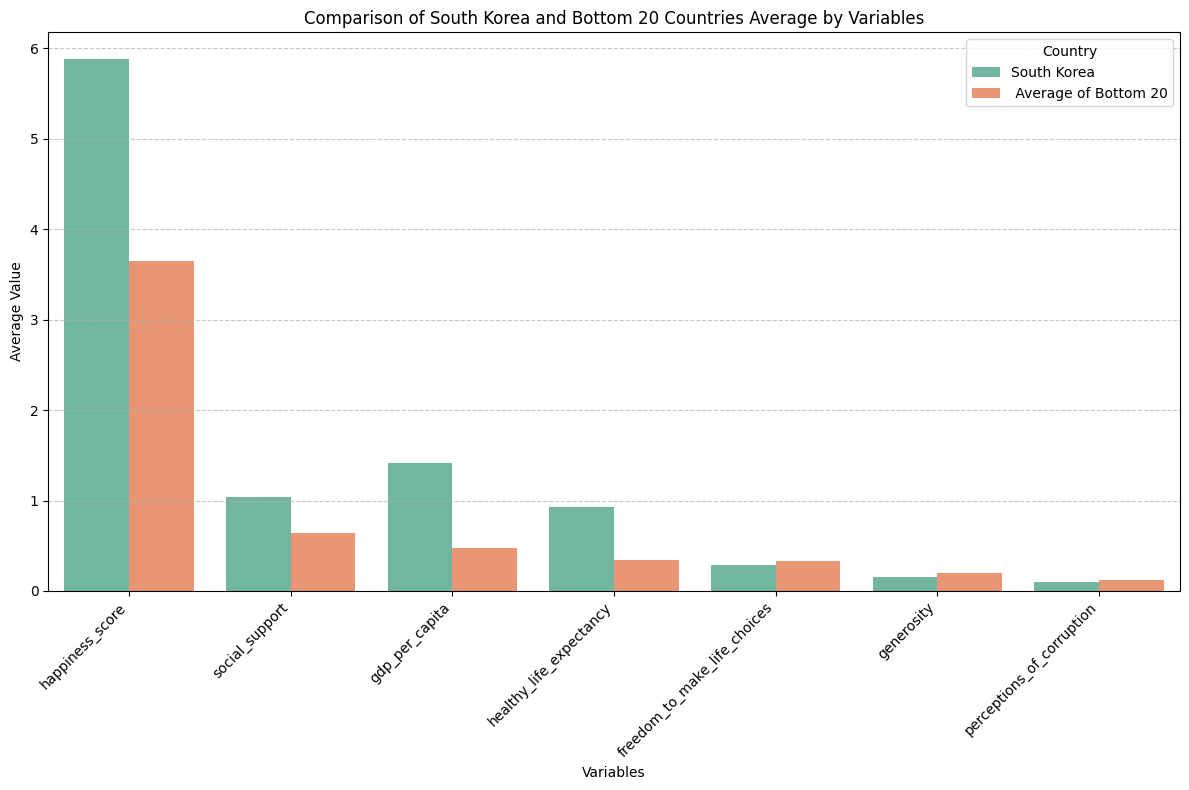

In [13]:
# 1. 한국과 happiness_score bottom 20 나라 선택
bottom_20 = df_avg.nsmallest(20, 'happiness_score')  # happiness_score가 낮은 20개 나라
south_korea = df_avg[df_avg['country'] == 'South Korea']  # 한국 데이터

# 2. bottom_20 국가들의 평균 계산
bottom_20_mean = bottom_20.select_dtypes(include=['float64', 'int64']).mean()

# 3. 한국과 bottom_20 평균 비교를 위한 데이터 준비
# 한국 데이터와 bottom_20 평균을 합침
comparison_data = pd.DataFrame({
    'country': ['South Korea', ' Average of Bottom 20'],
    'happiness_score': [south_korea['happiness_score'].values[0], bottom_20_mean['happiness_score']],
    'social_support': [south_korea['social_support'].values[0], bottom_20_mean['social_support']],
    'gdp_per_capita': [south_korea['gdp_per_capita'].values[0], bottom_20_mean['gdp_per_capita']],
    'healthy_life_expectancy': [south_korea['healthy_life_expectancy'].values[0], bottom_20_mean['healthy_life_expectancy']],
    'freedom_to_make_life_choices': [south_korea['freedom_to_make_life_choices'].values[0], bottom_20_mean['freedom_to_make_life_choices']],
    'generosity': [south_korea['generosity'].values[0], bottom_20_mean['generosity']],
    'perceptions_of_corruption': [south_korea['perceptions_of_corruption'].values[0], bottom_20_mean['perceptions_of_corruption']]
})

# 4. 데이터 Long Format으로 변환 (그래프를 그리기 위해서는 Long Format이 더 유리함)
comparison_data_long = comparison_data.melt(id_vars=["country"],
                                           value_vars=['happiness_score', 'social_support', 'gdp_per_capita',
                                                       'healthy_life_expectancy', 'freedom_to_make_life_choices',
                                                       'generosity', 'perceptions_of_corruption'],
                                           var_name='Variable',
                                           value_name='Value')

# 5. 막대그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(data=comparison_data_long, x='Variable', y='Value', hue='country', palette='Set2')

# 6. 그래프 꾸미기
plt.title('Comparison of South Korea and Bottom 20 Countries Average by Variables')
plt.xlabel('Variables')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')  # x축 라벨 회전
plt.legend(title='Country', loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# 7. 그래프 출력
plt.tight_layout()
plt.show()

**한국 vs Bottom20(avg)**


한국은 사회 지원, 경제 수준 (GDP), 건강한 기대 수명에서 훨씬 높은 수준을 보이고 있으며,<br> 이는 한국의 전반적인 생활 수준이 높다는 것을 시사합니다. <br>
반면, 삶의 선택 자유, 관대함, 부패 인식에서는 Bottom 20 국가들과 비교할 때 상대적으로 낮은 점수를 기록하고 있습니다.

### 한국의 전체 순위 분석

In [10]:
# happiness_score 기준으로 한국의 순위
rank_happiness_score = df_avg.sort_values(by='happiness_score', ascending=False).reset_index(drop=True)
korea_happiness_rank = rank_happiness_score[rank_happiness_score['country'] == 'South Korea'].index[0] + 1

# 그 외 변수들 기준 한국의 순위
rank_gdp = df_avg.sort_values(by='gdp_per_capita', ascending=False).reset_index(drop=True)
korea_gdp_rank = rank_gdp[rank_gdp['country'] == 'South Korea'].index[0] + 1

rank_social_support = df_avg.sort_values(by='social_support', ascending=False).reset_index(drop=True)
korea_social_support_rank = rank_social_support[rank_social_support['country'] == 'South Korea'].index[0] + 1

rank_health = df_avg.sort_values(by='healthy_life_expectancy', ascending=False).reset_index(drop=True)
korea_health_rank = rank_health[rank_health['country'] == 'South Korea'].index[0] + 1

rank_freedom = df_avg.sort_values(by='freedom_to_make_life_choices', ascending=False).reset_index(drop=True)
korea_freedom_rank = rank_freedom[rank_freedom['country'] == 'South Korea'].index[0] + 1

rank_generosity = df_avg.sort_values(by='generosity', ascending=False).reset_index(drop=True)
korea_generosity_rank = rank_generosity[rank_generosity['country'] == 'South Korea'].index[0] + 1

# ascending=True
rank_corruption = df_avg.sort_values(by='perceptions_of_corruption', ascending=True).reset_index(drop=True)
korea_corruption_rank = rank_corruption[rank_corruption['country'] == 'South Korea'].index[0] + 1

# 4. 한국의 순위 출력
print(f"나라 수: {df_avg['country'].nunique()}")
print(f"한국의 행복 점수 순위: {korea_happiness_rank}")
print(f"한국의 GDP 순위: {korea_gdp_rank}")
print(f"한국의 사회 지원 순위: {korea_social_support_rank}")
print(f"한국의 건강한 기대 수명 순위: {korea_health_rank}")
print(f"한국의 삶의 선택 자유 순위: {korea_freedom_rank}")
print(f"한국의 관대함 순위: {korea_generosity_rank}")
print(f"한국의 부패 인식 순위: {korea_corruption_rank}")

나라 수: 157
한국의 행복 점수 순위: 59
한국의 GDP 순위: 29
한국의 사회 지원 순위: 95
한국의 건강한 기대 수명 순위: 7
한국의 삶의 선택 자유 순위: 140
한국의 관대함 순위: 87
한국의 부패 인식 순위: 79


**강점**
1. 건강한 기대수명 (7위) <br>
   한국은 의료 서비스의 발달로 기대수명이 긴나라
2. GDP 순위 (29위)<br>
   경제력은 높은 편
3. 행복점수 (59위)<br>
   중위권 (경제력과 비교했을 때 상대적으로 낮음)

**약점**
1. 삶의 선택 자유 (140위)<br>
   사회적 압박이나 경쟁문화가 원인
2. 사회지원 (95위) <br>
   복지 살펴보기
3. 관대함 (87위)<br>
4. 부패인식(79위)
   정부나 기업의 부패에 대한 부정적인 인식


### 한국과 전체 평균 비교

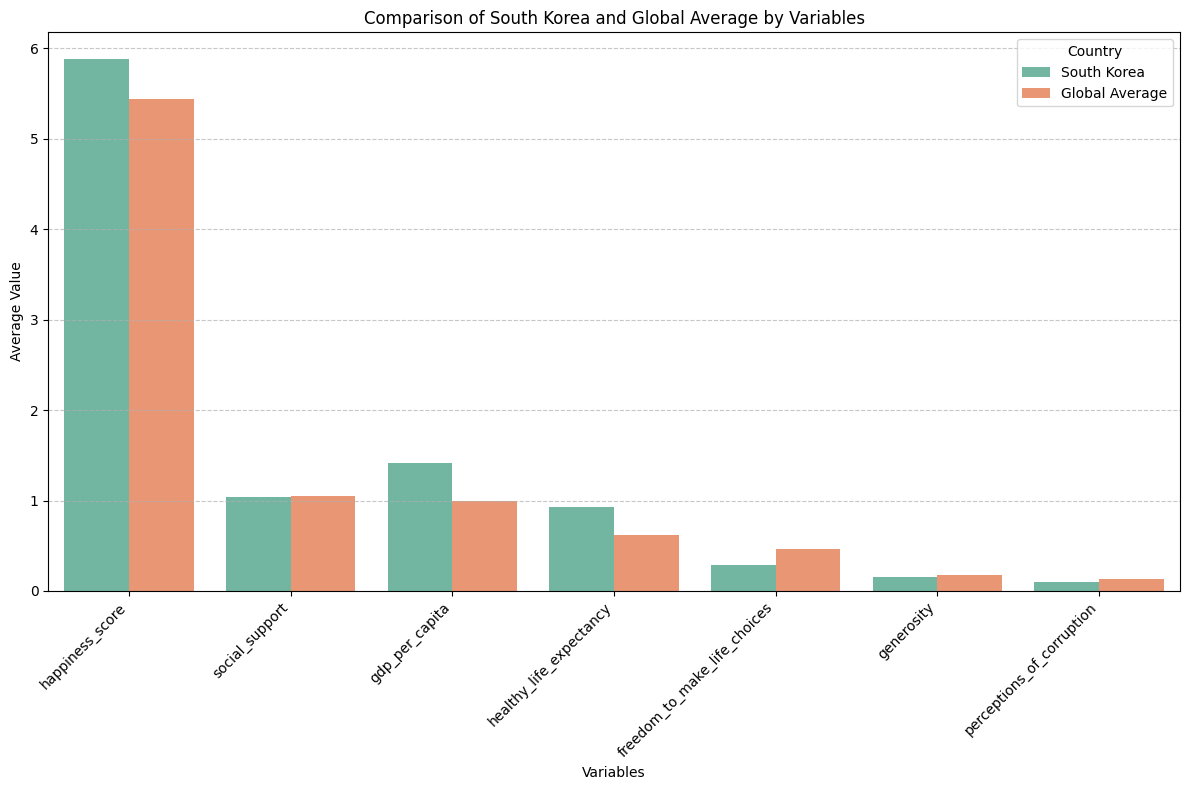

In [9]:
# 1. 전체 데이터 평균 계산
overall_mean = df_avg.select_dtypes(include=['float64', 'int64']).mean()

# 2. 한국과 전체 평균 비교를 위한 데이터 준비
comparison_data = pd.DataFrame({
    'country': ['South Korea', 'Global Average'],
    'happiness_score': [df_korea['happiness_score'].values[0], overall_mean['happiness_score']],
    'social_support': [df_korea['social_support'].values[0], overall_mean['social_support']],
    'gdp_per_capita': [df_korea['gdp_per_capita'].values[0], overall_mean['gdp_per_capita']],
    'healthy_life_expectancy': [df_korea['healthy_life_expectancy'].values[0], overall_mean['healthy_life_expectancy']],
    'freedom_to_make_life_choices': [df_korea['freedom_to_make_life_choices'].values[0], overall_mean['freedom_to_make_life_choices']],
    'generosity': [df_korea['generosity'].values[0], overall_mean['generosity']],
    'perceptions_of_corruption': [df_korea['perceptions_of_corruption'].values[0], overall_mean['perceptions_of_corruption']]
})

# 3. 데이터 Long Format으로 변환 (그래프를 그리기 위해서는 Long Format이 더 유리함)
comparison_data_long = comparison_data.melt(id_vars=["country"],
                                           value_vars=['happiness_score', 'social_support', 'gdp_per_capita',
                                                       'healthy_life_expectancy', 'freedom_to_make_life_choices',
                                                       'generosity', 'perceptions_of_corruption'],
                                           var_name='Variable',
                                           value_name='Value')

# 4. 막대그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(data=comparison_data_long, x='Variable', y='Value', hue='country', palette='Set2')

# 5. 그래프 꾸미기
plt.title('Comparison of South Korea and Global Average by Variables')
plt.xlabel('Variables')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')  # x축 라벨 회전
plt.legend(title='Country', loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# 6. 그래프 출력
plt.tight_layout()
plt.show()

### 한국과 top20 평균 비교

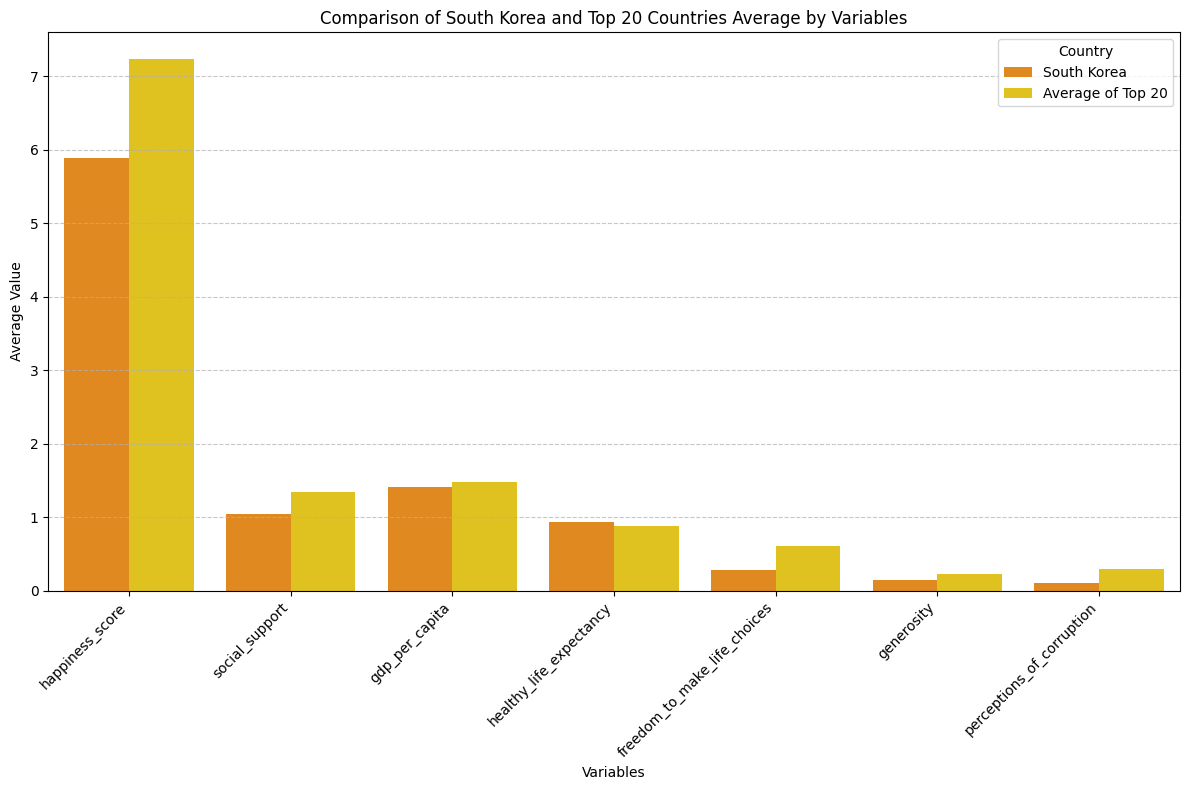

In [12]:
# 1. 행복지수 상위 20개국 선택
top_20 = df_avg.nlargest(20, 'happiness_score')

# 2. top 20 국가들의 평균 계산
top_20_mean = top_20.select_dtypes(include=['float64', 'int64']).mean()

# 3. 한국과 top_20 평균 비교를 위한 데이터 준비
comparison_data = pd.DataFrame({
    'country': ['South Korea', 'Average of Top 20'],
    'happiness_score': [df_korea['happiness_score'].values[0], top_20_mean['happiness_score']],
    'social_support': [df_korea['social_support'].values[0], top_20_mean['social_support']],
    'gdp_per_capita': [df_korea['gdp_per_capita'].values[0], top_20_mean['gdp_per_capita']],
    'healthy_life_expectancy': [df_korea['healthy_life_expectancy'].values[0], top_20_mean['healthy_life_expectancy']],
    'freedom_to_make_life_choices': [df_korea['freedom_to_make_life_choices'].values[0], top_20_mean['freedom_to_make_life_choices']],
    'generosity': [df_korea['generosity'].values[0], top_20_mean['generosity']],
    'perceptions_of_corruption': [df_korea['perceptions_of_corruption'].values[0], top_20_mean['perceptions_of_corruption']]
})

# 4. 데이터 Long Format으로 변환 (그래프를 그리기 위해서는 Long Format이 더 유리함)
comparison_data_long = comparison_data.melt(id_vars=["country"],
                                           value_vars=['happiness_score', 'social_support', 'gdp_per_capita',
                                                       'healthy_life_expectancy', 'freedom_to_make_life_choices',
                                                       'generosity', 'perceptions_of_corruption'],
                                           var_name='Variable',
                                           value_name='Value')

# 5. 색상 지정
colors = {'South Korea': '#FF8C00', 'Average of Top 20': '#FFD700'}  # 주황 & 노랑

# 6. 막대그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(data=comparison_data_long, x='Variable', y='Value', hue='country', palette=colors)

# 7. 그래프 꾸미기
plt.title('Comparison of South Korea and Top 20 Countries Average by Variables')
plt.xlabel('Variables')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')  # x축 라벨 회전
plt.legend(title='Country', loc='upper right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# 8. 그래프 출력
plt.tight_layout()
plt.show()

### GDP 와 Happiness Score 산점도

In [85]:
import plotly.express as px

# 한국만 빨간색, 나머지는 회색으로 설정
df_avg['color'] = df_avg['country'].apply(lambda x: 'red' if x == 'South Korea' else 'gray')

# 산점도 생성
fig = px.scatter(
    df_avg,
    x='gdp_per_capita',
    y='happiness_score',
    hover_name='country',  # 마우스 오버 시 표시될 값
    color=df_avg['color'],  # 색상 적용
    color_discrete_map={'red': 'red', 'gray': 'gray'}  # 색상 맵핑
)

# 그래프 제목 및 레이블 설정
fig.update_layout(
    title='Happiness Score vs GDP per Capita',
    xaxis_title='GDP per Capita',
    yaxis_title='Happiness Score',
    template='plotly_white'  # 배경 스타일 설정
)

# 점 크기 및 투명도 조정
fig.update_traces(marker=dict(size=8, opacity=0.7))

# 그래프 출력
fig.show()


### 한국과 GDP 비슷한 나라들 비교

<ipython-input-11-2c56459a4971>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparison_gdp_similar_long = comparison_gdp_similar_long.groupby('variable', group_keys=False).apply(


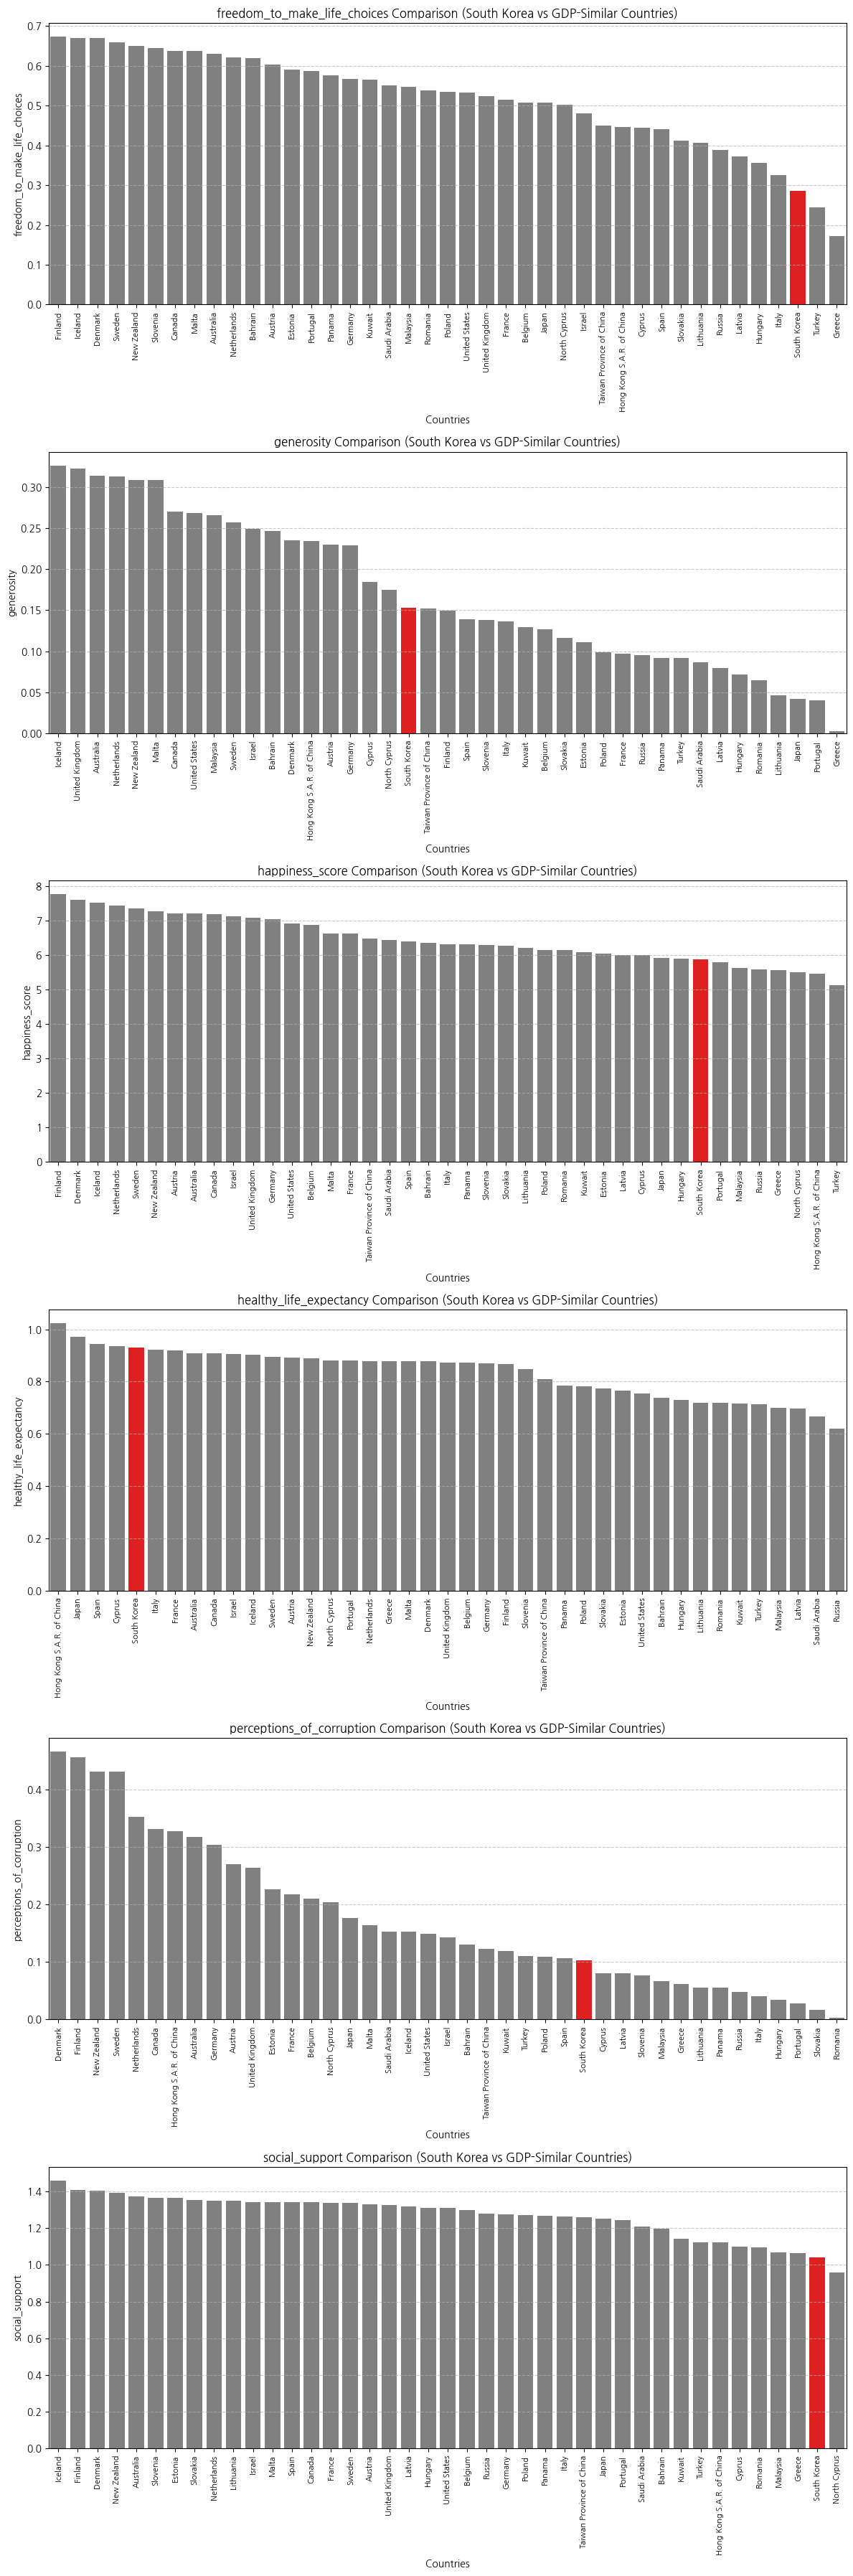

In [11]:
# 1. 한국의 GDP 확인
korea_gdp = df_avg[df_avg['country'] == 'South Korea']['gdp_per_capita'].values[0]

# 2. 한국과 GDP가 비슷한 국가 찾기 (±10% 이내)
gdp_similar_countries = df_avg[(df_avg['gdp_per_capita'] >= korea_gdp * 0.9) &
                               (df_avg['gdp_per_capita'] <= korea_gdp * 1.1)].copy()

# 3. 한국과 비교를 위한 데이터프레임
comparison_gdp_similar = gdp_similar_countries[['country', 'happiness_score', 'social_support',
                                                'healthy_life_expectancy', 'freedom_to_make_life_choices',
                                                'generosity', 'perceptions_of_corruption', 'gdp_per_capita']]

# 4. 각 변수별로 Long Format으로 변환 (그래프를 위해)
# melt() : wide format 데이터를 long format으로 변환
comparison_gdp_similar_long = comparison_gdp_similar.melt(id_vars='country',
                                                           value_vars=['happiness_score', 'social_support',
                                                                       'healthy_life_expectancy',
                                                                       'freedom_to_make_life_choices',
                                                                       'generosity', 'perceptions_of_corruption'])

# 5. 각 변수별 값에 대해 오름차순으로 정렬 (variable별로)
comparison_gdp_similar_long = comparison_gdp_similar_long.groupby('variable', group_keys=False).apply(
    lambda x: x.sort_values(by='value', ascending=False)).reset_index(drop=True)

# 6. 한국을 빨간색으로 표시하기 위한 컬러 매핑
# 'South Korea'를 빨간색으로, 나머지 국가들은 회색으로 표시
comparison_gdp_similar_long['color'] = comparison_gdp_similar_long['country'].apply(
    lambda x: 'red' if x == 'South Korea' else 'gray')

# 7. 그래프 그리기
variables = comparison_gdp_similar_long['variable'].unique()
num_variables = len(variables)

# 서브플롯 설정: 변수별로 하나의 그래프를 그리기 위해 nrows와 ncols로 배치
fig, axes = plt.subplots(nrows=num_variables, ncols=1, figsize=(12, 6 * num_variables))

# x축 레이블 간격을 조정
def adjust_x_ticks(ax, data):
    # 레이블이 많을수록 회전각도나 글자 크기 등을 동적으로 조정
    num_labels = len(data['country'].unique())
    if num_labels > 10:
        ax.tick_params(axis='x', rotation=90, labelsize=8)
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)

for i, variable in enumerate(variables):
    ax = axes[i]  # 각 변수별 서브플롯
    data = comparison_gdp_similar_long[comparison_gdp_similar_long['variable'] == variable]

    # 각 변수별로 그래프 그리기
    sns.barplot(data=data, x='country', y='value', hue='country', ax=ax, palette=data['color'].tolist())

    # 그래프 꾸미기
    ax.set_title(f'{variable} Comparison (South Korea vs GDP-Similar Countries)')
    ax.set_xlabel('Countries')
    ax.set_ylabel(variable)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    # x축 레이블 간격을 동적으로 조정
    adjust_x_ticks(ax, data)

    # 나라 라벨 제거 (legend에서만 표시)
    if ax.get_legend():
        ax.get_legend().remove()

# 서브플롯 간격 조정
plt.subplots_adjust(hspace=0.6)  # 서브플롯 간격을 적절히 조정하여 겹침 방지

# 레이아웃 최적화
plt.tight_layout()
plt.show()

<ipython-input-18-575abcef1be2>:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparison_gdp_similar_long = comparison_gdp_similar_long.groupby('variable', group_keys=False).apply(
<ipython-input-18-575abcef1be2>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='country', y='value', ax=ax, palette=colors)
<ipython-input-18-575abcef1be2>:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

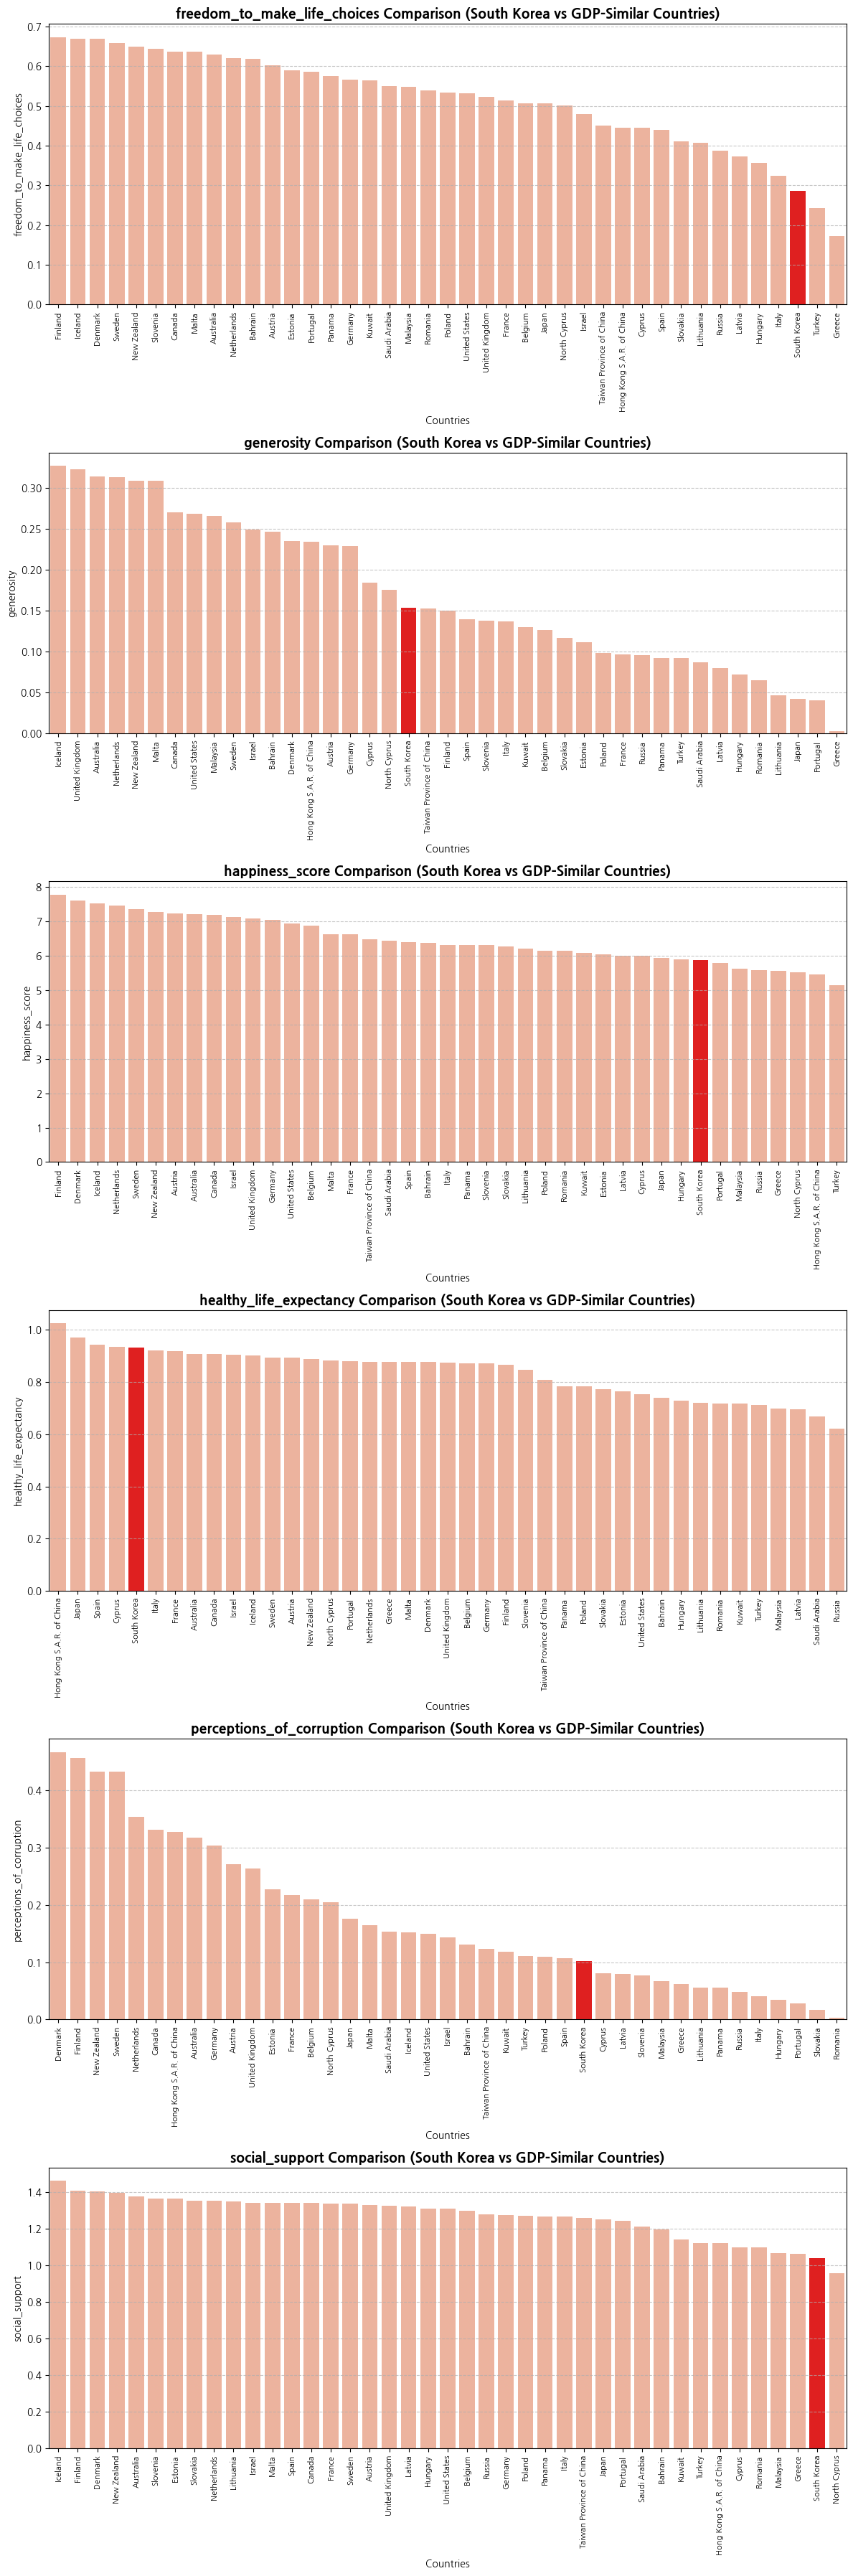

In [18]:
# 그래프 색상 변환

# 1. 한국의 GDP 확인
korea_gdp = df_avg[df_avg['country'] == 'South Korea']['gdp_per_capita'].values[0]

# 2. 한국과 GDP가 비슷한 국가 찾기 (±10% 이내)
gdp_similar_countries = df_avg[(df_avg['gdp_per_capita'] >= korea_gdp * 0.9) &
                               (df_avg['gdp_per_capita'] <= korea_gdp * 1.1)].copy()

# 3. 한국과 비교를 위한 데이터프레임
comparison_gdp_similar = gdp_similar_countries[['country', 'happiness_score', 'social_support',
                                                'healthy_life_expectancy', 'freedom_to_make_life_choices',
                                                'generosity', 'perceptions_of_corruption', 'gdp_per_capita']]

# 4. Long Format으로 변환
comparison_gdp_similar_long = comparison_gdp_similar.melt(id_vars='country',
                                                           value_vars=['happiness_score', 'social_support',
                                                                       'healthy_life_expectancy',
                                                                       'freedom_to_make_life_choices',
                                                                       'generosity', 'perceptions_of_corruption'])

# 5. 변수별 정렬
comparison_gdp_similar_long = comparison_gdp_similar_long.groupby('variable', group_keys=False).apply(
    lambda x: x.sort_values(by='value', ascending=False)).reset_index(drop=True)

# 6. 색상 매핑
def get_colors(countries):
    color_mapping = {country: "#f9ad91" for country in countries}  # 모든 나라 노란색
    color_mapping["South Korea"] = "red"  # 한국만 빨간색
    return [color_mapping[country] for country in countries]

# 7. 그래프 그리기
variables = comparison_gdp_similar_long['variable'].unique()
num_variables = len(variables)

fig, axes = plt.subplots(nrows=num_variables, ncols=1, figsize=(12, 6 * num_variables))

# x축 레이블 간격 조정 함수
def adjust_x_ticks(ax, data):
    num_labels = len(data['country'].unique())
    if num_labels > 10:
        ax.tick_params(axis='x', rotation=90, labelsize=8)
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)

for i, variable in enumerate(variables):
    ax = axes[i]
    data = comparison_gdp_similar_long[comparison_gdp_similar_long['variable'] == variable]

    # 색상 적용
    colors = get_colors(data['country'].unique())

    # 바 플롯 그리기
    sns.barplot(data=data, x='country', y='value', ax=ax, palette=colors)

    # 그래프 꾸미기
    ax.set_title(f'{variable} Comparison (South Korea vs GDP-Similar Countries)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Countries')
    ax.set_ylabel(variable)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    # x축 조정
    adjust_x_ticks(ax, data)

# 서브플롯 간격 조정
plt.subplots_adjust(hspace=0.6)
plt.tight_layout()
plt.show()


- GDP 비슷한 국가들에서 한국의 변수별 순위

In [59]:
# (행의 개수)비슷한 국가들 개수
print("한국과 gdp가 ±10% 이내로 차이나는 국가들:", gdp_similar_countries.shape[0],"개의 국가")

한국과 gdp가 ±10% 이내로 차이나는 국가들: 41 개의 국가


In [58]:
# gdp 비슷한 국가들에서 한국의 순위
similar_rank_gdp = gdp_similar_countries.sort_values(by='gdp_per_capita', ascending=False).reset_index(drop=True)
gdpsimilar_korea_gdp_rank = similar_rank_gdp[similar_rank_gdp['country'] == 'South Korea'].index[0] + 1

similar_rank_social_support = gdp_similar_countries.sort_values(by='social_support', ascending=False).reset_index(drop=True)
gdpsimilar_korea_social_support_rank = similar_rank_social_support[similar_rank_social_support['country'] == 'South Korea'].index[0] + 1

similar_rank_health = gdp_similar_countries.sort_values(by='healthy_life_expectancy', ascending=False).reset_index(drop=True)
gdpsimilar_korea_health_rank = similar_rank_health[similar_rank_health['country'] == 'South Korea'].index[0] + 1

similar_rank_freedom = gdp_similar_countries.sort_values(by='freedom_to_make_life_choices', ascending=False).reset_index(drop=True)
gdpsimilar_korea_freedom_rank = similar_rank_freedom[similar_rank_freedom['country'] == 'South Korea'].index[0] + 1

similar_rank_generosity = gdp_similar_countries.sort_values(by='generosity', ascending=False).reset_index(drop=True)
gdpsimilar_korea_generosity_rank = similar_rank_generosity[similar_rank_generosity['country'] == 'South Korea'].index[0] + 1

# ascending=True
similar_rank_corruption = gdp_similar_countries.sort_values(by='perceptions_of_corruption', ascending=True).reset_index(drop=True)
gdpsimilar_korea_corruption_rank = similar_rank_corruption[similar_rank_corruption['country'] == 'South Korea'].index[0] + 1

# 4. 한국의 순위 출력
print(f"한국의 GDP 순위: {gdpsimilar_korea_gdp_rank}")
print(f"한국의 사회 지원 순위: {gdpsimilar_korea_social_support_rank}")
print(f"한국의 건강한 기대 수명 순위: {gdpsimilar_korea_health_rank}")
print(f"한국의 삶의 선택 자유 순위: {gdpsimilar_korea_freedom_rank}")
print(f"한국의 관대함 순위: {gdpsimilar_korea_generosity_rank}")
print(f"한국의 부패 인식 순위: {gdpsimilar_korea_corruption_rank}")

한국의 GDP 순위: 22
한국의 사회 지원 순위: 40
한국의 건강한 기대 수명 순위: 5
한국의 삶의 선택 자유 순위: 39
한국의 관대함 순위: 19
한국의 부패 인식 순위: 14


→ 41개국 중 한국의 사회 지원 (40위), 한국의 삶의 선택 자유(39위)로 두가지 지표가 낮은 순위인것을 확인했다.

#### G12 국가 한국 비교

In [24]:
import pandas as pd

# 1. G12 국가 리스트 정의
g12_countries = ['United States', 'United Kingdom', 'Germany', 'France', 'Japan', 'Canada',
                 'Italy', 'Russia', 'South Korea', 'Australia', 'India', 'Brazil']

# 2. G12 국가들의 행복지수 (happiness_score) 추출
g12_happiness = df_avg[df_avg['country'].isin(g12_countries)][['country', 'happiness_score']]

# 3. 행복지수 내림차순으로 정렬 (순위 매기기)
g12_happiness_sorted = g12_happiness.sort_values(by='happiness_score', ascending=False).reset_index(drop=True)

# 4. 한국의 순위 찾기
korea_rank = g12_happiness_sorted[g12_happiness_sorted['country'] == 'South Korea'].index[0] + 1

# 5. 한국 순위 출력
print(f"한국의 G12 국가 내 순위: {korea_rank}")

# 6. G12 국가별 행복지수 출력
print(g12_happiness_sorted)


한국의 G12 국가 내 순위: 10
           country  happiness_score
0        Australia          7.21356
1           Canada          7.19322
2   United Kingdom          7.08310
3          Germany          7.04296
4    United States          6.92912
5           France          6.62436
6           Brazil          6.34352
7            Italy          6.31208
8            Japan          5.93016
9      South Korea          5.88448
10          Russia          5.58800
11           India          3.87486


<ipython-input-26-54047e43abd0>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=g12_happiness_sorted, x='country', y='happiness_score', palette=g12_happiness_sorted['color'].tolist())


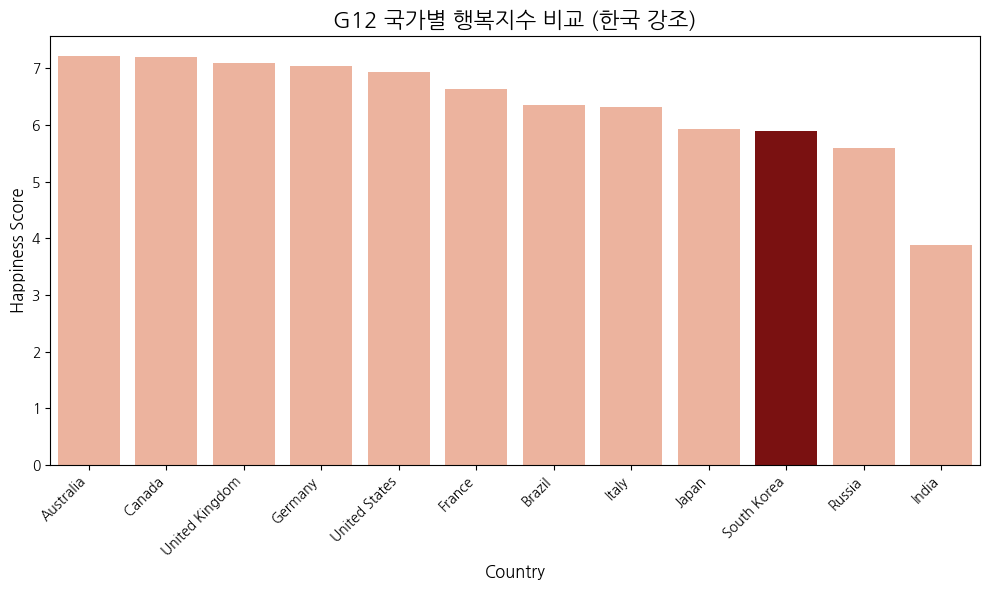

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한국은 진한 빨간색, 다른 나라들은 #F9AD91 색상으로 설정
g12_happiness_sorted['color'] = g12_happiness_sorted['country'].apply(
    lambda x: 'darkred' if x == 'South Korea' else '#F9AD91')

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.barplot(data=g12_happiness_sorted, x='country', y='happiness_score', palette=g12_happiness_sorted['color'].tolist())

# 제목, 레이블 설정
plt.title('G12 국가별 행복지수 비교', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)

# 한국을 강조하기 위한 텍스트 추가
korea_score = g12_happiness_sorted[g12_happiness_sorted['country'] == 'South Korea']['happiness_score'].values[0]
#plt.text(0, korea_score + 0.05, f'한국: {korea_score:.2f}', color='black', ha='center', fontweight='bold')

# 그래프 출력
plt.xticks(rotation=45, ha='right')  # X축 레이블 회전
plt.tight_layout()
plt.show()


### 참고 자료

**OECD Better Life Index**에서 한국의 자유도와 사회지원에 관련해 참고 <br>
OBS_VALUE: 해당 지표의 값 (여기서는 각 국가별 노동 시장 불안정성 값)<br>
<br>
**노동시장이 불안정**이 높다는 것은 **높은 실업률, 고용 불안정성, 정부의 고용 정책 부족** 등의 가능성이 있다.

[[사이트] OECD Better Life Index](https://www.oecdbetterlifeindex.org/#/11111111111) <br>
[[데이터]](https://data-explorer.oecd.org/vis?tenant=archive&df[ds]=DisseminateArchiveDMZ&df[id]=DF_BLI&df[ag]=OECD&dq=...&to[TIME]=false)

#### INDICATOR 컬럼의 UNIQUE


🏡 **주거 (Housing)**
- **HO_BASE**: 기본적인 주거 시설 (Basic housing facilities)  
- **HO_HISH**: 주거비용 부담률 (Housing cost burden)  
- **HO_NUMR**: 1인당 방 개수 (Rooms per person)  

💼 **노동 & 고용 (Jobs & Earnings)**
- **JE_LMIS**: 노동시장 불안정성 (Labour market insecurity)  
- **JE_EMPL**: 고용률 (Employment rate)  
- **JE_LTUR**: 장기 실업률 (Long-term unemployment rate)  
- **JE_PEARN**: 평균 소득 (Personal earnings)  

📚 **교육 (Education)**
- **ES_EDUA**: 성인 교육 수준 (Adult skills)  
- **ES_STCS**: 학생 교사 비율 (Student-teacher ratio)  
- **ES_EDUEX**: 교육 지출 (Educational expenditure)  

🏥 **건강 (Health)**
- **HS_LEB**: 기대 수명 (Life expectancy at birth)  
- **HS_SFRH**: 자기보고 건강 상태 (Self-reported health)  

🌍 **환경 (Environment)**
- **EQ_WATER**: 깨끗한 물에 대한 접근성 (Access to clean water)  
- **EQ_AIRP**: 대기 오염 (Air pollution)  

🗳️ **시민 참여 & 거버넌스 (Civic Engagement)**
- **CG_VOTO**: 투표율 (Voter turnout)  
- **CG_SENG**: 정부에 대한 신뢰 (Confidence in government)  

🤝 **사회적 관계 (Social connections)**
- **SC_SNTWS**: 사회적 네트워크 및 지원 (Social support networks)  

⚖️ **안전 (Safety)**
- **PS_FSAFEN**: 여성의 안전 (Female safety)  
- **PS_REPH**: 살인율 (Homicide rate)  

😊 **삶의 만족도 & 균형 (Well-being & Work-life balance)**
- **SW_LIFS**: 삶의 만족도 (Life satisfaction)  
- **WL_TNOW**: 여가 및 개인 시간 (Time spent on leisure and personal care)  
- **WL_EWLH**: 초과 근무 시간 (Employees working long hours)  

📈 **소득 & 부 (Income & Wealth)**
- **IW_HADI**: 가처분 소득 (Household adjusted disposable income)  
- **IW_HNFW**: 순자산 (Household net financial wealth)  


### **Social Support(사회 지원)**

In [63]:
worklifebalance = pd.read_csv("/content/drive/MyDrive/mid/OECD,DF_BLI,+all.csv")
# worklifebalance.head()

In [28]:
worklifebalance["INDICATOR"].unique()

array(['JE_LMIS', 'HO_BASE', 'PS_FSAFEN', 'HO_HISH', 'JE_EMPL', 'JE_LTUR',
       'SC_SNTWS', 'ES_EDUA', 'EQ_WATER', 'CG_VOTO', 'HS_SFRH', 'WL_EWLH',
       'CG_SENG', 'ES_STCS', 'SW_LIFS', 'HO_NUMR', 'IW_HADI', 'IW_HNFW',
       'JE_PEARN', 'ES_EDUEX', 'EQ_AIRP', 'HS_LEB', 'PS_REPH', 'WL_TNOW'],
      dtype=object)

#### 노동시장의 불안정성 : Labour market insecurity (JE_LMIS)
- OBS_VALUE 값이 **높을수록** 노동 시장이 **불안정**한 국가
- OBS_VALUE 값이 **낮을수록** 노동 시장이 **안정적**인 국가

In [5]:
je_lmis= worklifebalance[worklifebalance['INDICATOR']=='JE_LMIS']

In [6]:
je_lmis = je_lmis.sort_values(by="OBS_VALUE", ascending=False)

# 순위
rank = je_lmis.reset_index().index[je_lmis["Country"] == "Korea"][0] + 1

# 출력
print(f"나라 수: {je_lmis.shape[0]}")
print(f"한국의 노동 시장 불안정성 순위: {rank}")

나라 수: 35
한국의 노동 시장 불안정성 순위: 24


In [16]:
len(je_lmis["Country"].unique()) # 겹치는 나라 없음

35

In [17]:
# OECD 평균 계산
oecd_avg = je_lmis["OBS_VALUE"].mean()

# 한국의 노동 시장 불안정성 값 가져오기
korea_value = je_lmis[je_lmis["Country"] == "Korea"]["OBS_VALUE"].values[0]

# 한국과 OECD 평균 비교
diff = korea_value - oecd_avg

# 결과 출력
print(f"OECD 평균 노동 시장 불안정성: {oecd_avg:.2f}")
print(f"한국의 노동 시장 불안정성: {korea_value:.2f}")
print(f"한국과 OECD 평균 차이: {diff:.2f}")

# 차이에 따른 해석
if diff > 0:
    print("한국의 노동 시장 불안정성이 OECD 평균보다 높음. (한국의 노동 시장이 평균보다 불안정)")
elif diff < 0:
    print("한국의 노동 시장 불안정성이 OECD 평균보다 낮음. (한국의 노동 시장이 평균보다 안정적)")
else:
    print("한국의 노동 시장 불안정성이 OECD 평균과 동일함")


OECD 평균 노동 시장 불안정성: 5.18
한국의 노동 시장 불안정성: 2.90
한국과 OECD 평균 차이: -2.28
한국의 노동 시장 불안정성이 OECD 평균보다 낮음. (한국의 노동 시장이 평균보다 안정적)


- 결과
→ 35개국 중 불안정성 순위는 24/ 평균보다 안정적인 노동시장<br>
  OBS_VALUE 값이 높을 수록 불안정성이 크므로 **한국은 OECD 국가중 안정적인 편**에 속함, <br>
  하지만 상위권과 비교했을 때 **개선의 여지는 보임**

#### OECD 상위권과 비교(je_lmis)



In [18]:
# je_lmis OBS_VALUE 값이 낮은 나라 TOP 10(안정적인 나라)

je_lmis.sort_values(by='OBS_VALUE', ascending=True).head(10)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,...,OBS_VALUE,Observation Value,OBS_STATUS,Observation Status,UNIT_MEASURE,Unit of Measures,UNIT_MULT,Multiplier,BASE_PER,Base reference period
10,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,ISL,Iceland,JE_LMIS,Labour market insecurity,L,Value,...,1.0,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
7,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,DEU,Germany,JE_LMIS,Labour market insecurity,L,Value,...,1.4,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
15,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,LUX,Luxembourg,JE_LMIS,Labour market insecurity,L,Value,...,2.2,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
5,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,FIN,Finland,JE_LMIS,Labour market insecurity,L,Value,...,2.2,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
3,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,CZE,Czechia,JE_LMIS,Labour market insecurity,L,Value,...,2.3,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
0,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,AUT,Austria,JE_LMIS,Labour market insecurity,L,Value,...,2.3,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
1,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,BEL,Belgium,JE_LMIS,Labour market insecurity,L,Value,...,2.4,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
17,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,NLD,Netherlands,JE_LMIS,Labour market insecurity,L,Value,...,2.5,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
11,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,IRL,Ireland,JE_LMIS,Labour market insecurity,L,Value,...,2.6,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
13,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,JPN,Japan,JE_LMIS,Labour market insecurity,L,Value,...,2.7,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN


💡 한국에 대한 시사점

    한국은 주 52시간제 도입과 같은 노동 시간 규제는 있지만, 비정규직 문제와 실업 지원 제도는 상대적으로 부족/
    중소기업과 비정규직의 고용 안정성은 상대적으로 낮음


#### **노동시장안정성 OECD top10 안정성 요인 분석**
**🇮🇸 1. 아이슬란드 (Iceland)**

- 노동 보호법이 강력하며, 해고가 매우 어렵고 노동자가 법적으로 보호받음.
- 적극적인 실업자 재취업 지원(Job Integration Support) 정책 운영.
- 최저임금이 높고, 근로자의 권리를 강하게 보장.
- 노동조합의 협상력이 매우 강해 노동자 보호가 철저함.

**🇩🇪 2. 독일 (Germany)**

- 정규직 보호법이 강력하며, 기업이 노동자를 쉽게 해고할 수 없음.
- 노동조합과 기업 간 협력이 잘 이루어짐.

**🇱🇺 3. 룩셈부르크 (Luxembourg)**
- 유럽에서 최저임금이 가장 높은 수준 (약 €2,500 이상).
- 사회보장 시스템이 탄탄하여, 실업 시에도 지원이 충분함.
- 기업의 노동자 해고가 어렵고, 정규직 안정성이 높음.

**🇫🇮 4. 핀란드 (Finland)**
- 노사 협력이 강력하여 노동시장 안정성이 높음.
- 강력한 사회보장 제도 덕분에 실업자의 생활이 보장됨.
- 유연한 근무제도 도입으로 워라밸이 보장됨 (예: 6시간 근무제 시도).

**🇨🇿 5. 체코 (Czechia)**
- 실업률이 낮음 (약 2.5% 수준).
- 국가 차원의 직업 교육 제도가 발달하여 실업을 예방함.
- 노동법이 비교적 유연하지만, 사회적 안전망이 탄탄함.

**🇦🇹 6. 오스트리아 (Austria)**
- 적극적인 노동시장 정책 운영 (예: 실업자 훈련, 직업 전환 지원).
- 고용 안정성 보장이 강하고, 해고 절차가 까다로움.
- 실업급여 시스템이 효과적으로 운영됨.

**🇧🇪 7. 벨기에 (Belgium)**
- 노동조합이 강력하여 노동자 보호가 잘됨.
- 실업자 지원 정책이 우수하여, 실업 후 복귀가 원활.
- 유급 휴가와 근로 시간 규제가 잘 적용됨.

**🇳🇱 8. 네덜란드 (Netherlands)**
- 파트타임 근무 비율이 세계 최고 수준 (~40%).
- 탄력적 근무제도(예: 재택근무, 유연 근무제) 덕분에 실업률이 낮음.
- 실업보험과 사회보장제도가 잘 운영됨.

**🇮🇪 9. 아일랜드 (Ireland)**
- 기업 친화적 환경을 조성하여 외국인 투자를 활발히 유치.
- 실업보험 시스템이 잘 운영되어 노동 시장 안정성이 높음.
- 노동법이 유연하여, 기업들이 근로자를 쉽게 고용 가능.

**🇯🇵 10. 일본 (Japan)**
- 종신고용 (Lifetime Employment) 전통이 강해 노동 시장이 비교적 안정적.
- 기업 내 재교육 시스템이 활발하여 직업 안정성이 높음.
- 정규직과 비정규직 간 격차가 문제로 남아 있음.

#### **🇰🇷 한국이 강화하면 좋은 것 같은 점**
- 실업보험 & 사회보장 강화 (독일, 룩셈부르크, 벨기에)
- 탄력적 근무제 도입 확대 (네덜란드, 핀란드)
- 직업 훈련 & 재교육 제도 강화 (독일, 일본)
- 노사 협력 문화 정착 (핀란드, 독일)<br>

##### 1.직업훈련 & 재교육 제도 강화

  * 한국이 비교적 잘하고 있는 점
    1. 디지털 직업 교육 강화

      한국은 K-Digital Training 같은 프로그램을 운영하며 IT, AI, 빅데이터 등 미래 산업 중심의 직업 훈련을 제공 중.
      정부가 **"국민내일배움카드"**를 통해 직업 교육을 지원하는 것도 강점.

    2. 대기업 중심의 직무 전환 교육

      삼성, 현대, LG 등 대기업은 직무 전환 교육과 사내 재교육 시스템을 운영하며 직원들의 역량 강화를 지원.

    3. 청년층을 위한 취업 교육 프로그램

      정부가 운영하는 "청년 취업사관학교", 코딩·AI 부트캠프 등이 있음.
      일부 대학과 협력하여 실무 교육 제공.

  * 한국의 한계점 & 개선 방향
    
    1. 중소기업과 비정규직 근로자의 교육 접근성 부족

        대기업은 직업 교육이 활발하지만, 중소기업과 비정규직 근로자는 직업 훈련 기회가 적음.
        유럽은 중소기업도 정부 지원을 받아 재교육이 활발함.
        
    2. 실무형 훈련 부족 & 직업 교육 인식 부족

      한국은 대학 중심 사회라서, 직업학교(특성화고, 마이스터고 등)에 대한 인식이 낮음.
      독일은 **"이원적 교육 시스템(도제제도)"**을 통해 학교에서 이론을 배우면서 기업에서 실습도 진행.
    
    3. 고령층을 위한 재교육 시스템 미흡

      40~50대 이상 근로자들에게 전문적인 재교육 프로그램이 부족해서, 산업 변화에 적응하기 어려운 경우가 많음.
      핀란드, 네덜란드는 평생 교육 시스템을 통해 중장년층까지 적극적으로 재교육 지원.


      ✓ 한국은 청년층과 IT 직군 중심의 직업 훈련은 잘 이루어지고 있지만, 중소기업·고령층·비정규직을 위한 시스템은 부족한 편<br>
      유럽식 직업교육 모델(도제 시스템, 평생 교육)을 도입하고, 중소기업까지 확대

| 비교 항목             | 한국                                       | 핀란드  / 독일  / 네덜란드  |
|-------------------|------------------------------------------|--------------------------------------------|
| **정부 지원 프로그램** | ✅ 있음 (K-Digital Training, 직업훈련 바우처 등) | ✅ 있음 (강한 직업 교육 시스템, 평생 교육) |
| **기업 내 직무 전환 교육** | 🔄 대기업 위주로 있음 (삼성, 현대 등) | ✅ 중소기업까지 광범위하게 운영 |
| **직업 교육 체계** | ⚠️ 대학 중심, 실무형 교육 부족 | ✅ 직업학교, 도제 시스템 운영 |
| **재교육 접근성** | ❌ 40~50대 근로자에게 불리 | ✅ 전 연령층 대상 평생 교육 |
| **고용 연계성** | ⚠️ 교육 후에도 취업률이 낮은 경우 많음 | ✅ 기업과 협력하여 훈련 후 채용 |


##### 2.노사 협력 문화 정착 (핀란드, 독일)
  : 기업과 노동자간의 원활한 협의가 잘 이루어질 수 있는 제도 필요<br>
    ✓ 한국은 노사 협력이 부족한 국가 중 하나로 평가됨.<br>
    **노동조합 가입률(약 14%)이 낮고**, 노동법이 상대적으로 기업 중심으로 운영됨.

##### 3.탄력적 근무제 도입 확대

- 한국이 비교적 잘하고 있는 점
  1. IT·대기업 중심으로 원격근무 증가

    팬데믹 이후 네이버, 카카오, 삼성 등 일부 대기업과 IT 기업에서 재택근무, 유연근무제 도입 확대.
    일부 기업은 완전 재택근무(예: 당근마켓, 직방) 운영 중.
    **하지만 중소기업 및 전통 제조업에서는 여전히 제한적.**
  
  2.탄력근무제 법제화 (주 52시간제 개편)
    최근 정부가 **"탄력적 근무제"**를 확대하는 법 개정을 추진 중.
    하지만 현실적으로 기업들이 적극적으로 도입하지 **않는** 경우 많음.

- 한계점 및 개선방향
  
  1. 근로시간이 법적으로 너무 경직적

    한국은 주 52시간제로 인해 유연한 근무 스케줄을 짜기 어려운 구조.
    반면, 네덜란드·독일은 **"법적으로 직원이 원하는 근무시간을 선택할 권리"**가 보장됨.
  
  2. 재택근무가 특정 업종(IT·대기업) 중심

    핀란드, 네덜란드는 공공기관, 일반 사무직, 교육·의료 업종까지 재택근무 가능.
    한국은 제조업·서비스업은 거의 불가능, "사무직 위주로만 제한적 도입"되는 현실.

  3. 파트타임·단축근무 활용도 낮음

    한국에서는 파트타임 근무를 비정규직 위주로 운영해서 정규직 근로자들이 쉽게 이용하기 어려움.
    독일, 네덜란드는 정규직도 원하는 경우 근무시간을 줄이고, 다시 원할 때 풀타임으로 복귀 가능.

  4. 업무 성과 중심보다 "출퇴근 시간" 중심 문화

    한국은 여전히 **"직원들이 얼마나 오래 일하는지"**를 중요하게 보는 문화가 남아 있음.
    유럽은 **"일한 시간보다 성과"**를 중요하게 평가해서, 유연근무가 자연스럽게 자리 잡음.



      한국도 IT·대기업 중심으로 유연근무제가 점차 확대되고 있지만, 전체적인 도입률은 여전히 낮음.
      근로시간 선택권을 확대하고, 파트타임·재택근무를 보편화로 노동시장 안정성 높이기

| 비교 항목                          | 한국                                          | 네덜란드  / 독일  / 핀란드  |
|--------------------------------|----------------------------------------------|--------------------------------------------|
| **재택근무, 원격근무 가능성**   | ⚠️ 일부 대기업 및 IT 업종에서 가능                | ✅ 일반적이고 보편화됨                         |
| **근로시간 선택권 (시차출퇴근제, 주 4일제 등)** | ❌ 제한적, 시범 운영 수준                        | ✅ 일상화, 법적으로 보장됨                    |
| **파트타임 근무 선택권**        | ⚠️ 비정규직 위주                                  | ✅ 정규직도 자유롭게 이용 가능               |
| **근무시간 조정 권리**         | ❌ 회사 재량                                      | ✅ 직원이 요청하면 법적으로 보장됨            |
| **워라밸 수준**                 | 🔴 낮음 (OECD 최장 근로시간)                     | 🟢 높음 (OECD 최단 근로시간)                 |


##### 4.실업보험 & 사회보장 강화

한국은 최근 몇 년간 사회보장과 실업보험 제도를 강화하고 있으나, 여전히 **취약계층이나 비정규직 근로자에 대한 지원이 부족**한 상황 <br> OECD 국가들에 비해 사회보장 범위가 상대적으로 **좁고**, 고용보험이나 실업보험의 수혜 대상이 **제한적** <br>따라서 한국의 사회보장 시스템을 선진국 수준으로 끌어올리기 위한 추가적인 개선이 필요

#### 사회적 네트워크와 지원 : Social networks and support(SC_SNTWS)

사람들이 어려운 상황에서 가족이나 친구들에게 얼마나 도움을 받을 수 있는지에 대한 평가입니다. 사회적 연결망이 중요함

In [64]:
sc_sntws= worklifebalance[worklifebalance['INDICATOR']=='SC_SNTWS']
sc_sntws= sc_sntws.sort_values(by='OBS_VALUE', ascending=False)
sc_sntws.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,...,OBS_VALUE,Observation Value,OBS_STATUS,Observation Status,UNIT_MEASURE,Unit of Measures,UNIT_MULT,Multiplier,BASE_PER,Base reference period
573,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,FIN,Finland,SC_SNTWS,Quality of support network,L,Value,...,100.0,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
501,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,ISL,Iceland,SC_SNTWS,Quality of support network,L,Value,...,99.0,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
571,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,CZE,Czechia,SC_SNTWS,Quality of support network,L,Value,...,99.0,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
578,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,ISL,Iceland,SC_SNTWS,Quality of support network,L,Value,...,99.0,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN
535,DATAFLOW,OECD:DF_BLI(1.0),Better Life Index,I,FIN,Finland,SC_SNTWS,Quality of support network,L,Value,...,98.0,NaN,A,NaN,PC,Percentage,0,Units,NaN,NaN


In [65]:
# 한국 데이터가 여러개인 것을 확인
sc_sntws.reset_index().index[sc_sntws["Country"] == "Korea"]

Index([179, 181, 197, 200, 207], dtype='int64')

In [66]:
# 총 데이터 수
len(sc_sntws)

208

In [67]:
# 실제 데이터가 있는 나라 수
len(sc_sntws["Country"].unique())

42

- 왜 여러개의 데이터들이 들어가 있는걸까?

In [68]:
# 정보가 들어있는 컬럼명
sc_sntws.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'LOCATION',
       'Country', 'INDICATOR', 'Indicator', 'MEASURE', 'Measure', 'INEQUALITY',
       'Inequality', 'OBS_VALUE', 'Observation Value', 'OBS_STATUS',
       'Observation Status', 'UNIT_MEASURE', 'Unit of Measures', 'UNIT_MULT',
       'Multiplier', 'BASE_PER', 'Base reference period'],
      dtype='object')

In [69]:
# INEQUALITY(불평등) 컬럼 존재
sc_sntws["INEQUALITY"].unique()

array(['HGH', 'MN', 'WMN', 'TOT', 'LW'], dtype=object)

In [70]:
# OECD - Total 불평등 컬럼값으로 나눠서 계산되고 있음
sc_sntws[sc_sntws["Country"] == "OECD - Total"][["INEQUALITY", "MEASURE", "OBS_VALUE"]]

,INEQUALITY,MEASURE,OBS_VALUE
604,HGH,L,94.0
567,WMN,L,92.0
494,LW,L,91.0
489,TOT,L,91.0
528,MN,L,90.0


➞ 데이터가 **소득 수준**에 따라 나눠지고 있음  <br>
1. HGH : High income(고소득층)
2. MN  : Mean(평균)
3. WMN : Women(여성)
4. TOT : Total(전체)
5. LW  : Low income(저소득층)

#### 한국 순위



**1. TOTAL**

In [71]:
# TOT(total)
sc_sntws_tot = sc_sntws[sc_sntws["INEQUALITY"] == "TOT"]

In [72]:
# 한국의 순위 확인
korea_rank_sc_tot = sc_sntws_tot.reset_index().index[sc_sntws_tot["Country"] == "Korea"][0] + 1

# 출력
print(f"총 나라 수: {sc_sntws_tot.shape[0]}")
print(f"한국의 사회적 네트워크와 지원 순위: {korea_rank_sc_tot}")

총 나라 수: 42
한국의 사회적 네트워크와 지원 순위: 40


<ipython-input-73-95a0932ed6cd>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Rank", y="Country", data=sc_sntws_tot_sorted, palette="deep")


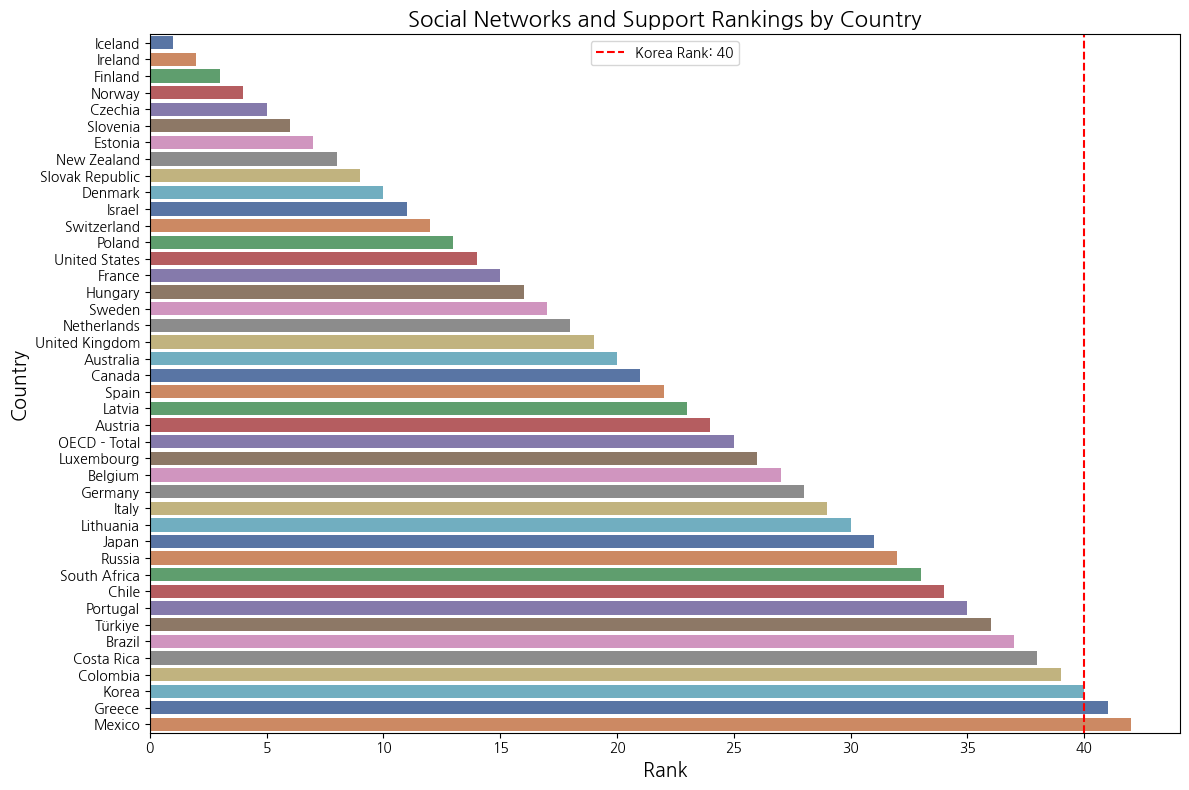

In [73]:
# 전체 국가의 순위 데이터 계산
sc_sntws_tot_sorted = sc_sntws_tot.sort_values(by="OBS_VALUE", ascending=False)
sc_sntws_tot_sorted["Rank"] = range(1, len(sc_sntws_tot_sorted) + 1)

# 한국의 순위 출력
korea_rank_sc_tot = sc_sntws_tot_sorted[sc_sntws_tot_sorted["Country"] == "Korea"]["Rank"].values[0]

# 전체 국가 순위 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x="Rank", y="Country", data=sc_sntws_tot_sorted, palette="deep")

# 한국의 순위 강조
plt.axvline(x=korea_rank_sc_tot, color='r', linestyle='--', label=f"Korea Rank: {korea_rank_sc_tot}")

# 그래프 제목과 레이블
plt.title("Social Networks and Support Rankings by Country", fontsize=16)
plt.xlabel("Rank", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.legend()

# 그래프 출력
plt.tight_layout()
plt.show()

**2. HGH(고소득층)**

In [74]:
sc_sntws_high = sc_sntws[sc_sntws["INEQUALITY"] == "HGH"]

In [75]:
# 한국의 순위 확인
korea_rank_sc_high = sc_sntws_high.reset_index().index[sc_sntws_high["Country"] == "Korea"][0] + 1

# 출력
print(f"총 나라 수: {sc_sntws_high.shape[0]}")
print(f"한국의 사회적 네트워크와 지원 순위: {korea_rank_sc_high}")

총 나라 수: 41
한국의 사회적 네트워크와 지원 순위: 40


**3.LW(저소득층)**

In [76]:
sc_sntws_low = sc_sntws[sc_sntws["INEQUALITY"] == "LW"]

In [77]:
# 한국의 순위 확인
korea_rank_sc_low = sc_sntws_low.reset_index().index[sc_sntws_low["Country"] == "Korea"][0] + 1

# 출력
print(f"총 나라 수: {sc_sntws_low.shape[0]}")
print(f"한국의 사회적 네트워크와 지원 순위: {korea_rank_sc_low}")

총 나라 수: 41
한국의 사회적 네트워크와 지원 순위: 40


**4.WMN(여성만)**

In [78]:
sc_sntws_women = sc_sntws[sc_sntws["INEQUALITY"] == "WMN"]

In [79]:
# 한국의 순위 확인
korea_rank_sc_women = sc_sntws_women.reset_index().index[sc_sntws_women["Country"] == "Korea"][0] + 1

# 출력
print(f"총 나라 수: {sc_sntws_women.shape[0]}")
print(f"한국의 사회적 네트워크와 지원 순위: {korea_rank_sc_women}")

총 나라 수: 42
한국의 사회적 네트워크와 지원 순위: 37


#### 가설 설정



- 고소득과 저소득층간에 obs_value간 격차가 클것이다. 즉, 소득이 많을 수록 사회적 지원이 더 활발하게 이루어질 것이다.<br>
- 한국은 전체적으로 사회적 네트워크 시스템이 좋지 않다.

In [80]:
oecd_avg = sc_sntws_tot[sc_sntws_tot["Country"] == "OECD - Total"]["OBS_VALUE"].values[0]
total_avg = sc_sntws_tot[sc_sntws_tot["Country"] == "Korea"]["OBS_VALUE"].values[0]
high_income_avg = sc_sntws_high[sc_sntws_high["Country"] == "Korea"]["OBS_VALUE"].values[0]
low_income_avg = sc_sntws_low[sc_sntws_low["Country"] == "Korea"]["OBS_VALUE"].values[0]


print(f"OECD 국가 평균: {oecd_avg}")
print(f"전체 평균 (TOT): {total_avg}")
print(f"고소득층 (HGH): {high_income_avg}")
print(f"저소득층 (LW): {low_income_avg}")

OECD 국가 평균: 91.0
전체 평균 (TOT): 80.0
고소득층 (HGH): 86.0
저소득층 (LW): 78.0


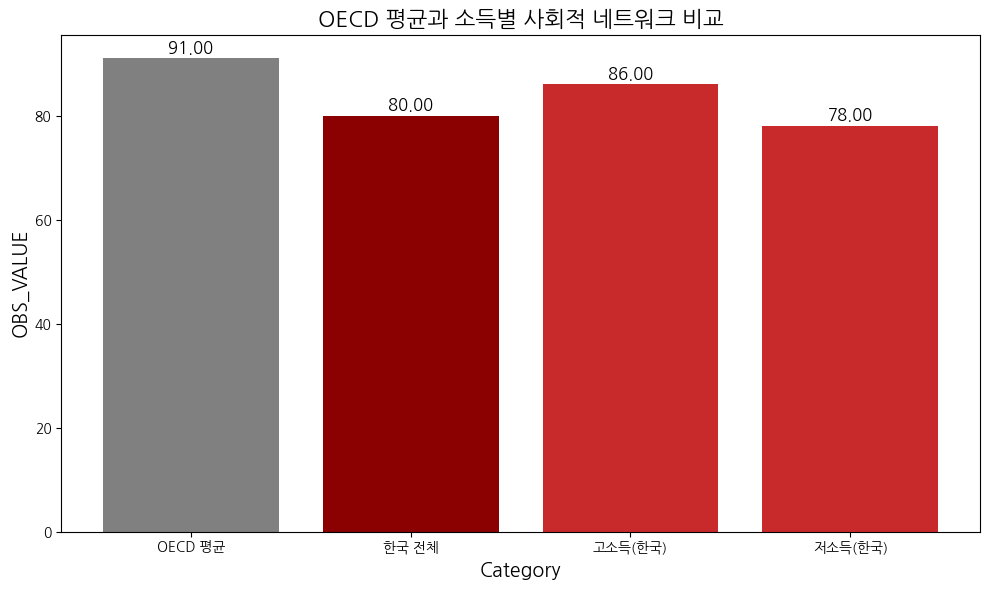

In [82]:
# 시각화
categories = ['OECD 평균', '한국 전체', '고소득(한국)', '저소득(한국)']
values = [oecd_avg, total_avg, high_income_avg, low_income_avg]

# 색상
colors = ['grey', 'darkred', '#c8292b', '#c8292b']

# 막대 그래프
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors)

# 각 막대 위에 값 표시
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x 위치
        bar.get_height() + 0.5,  # y 위치 (막대 위에 값 표시)
        f'{bar.get_height():.2f}',  # 표시할 값 (소수점 2자리)
        ha='center', va='bottom', fontsize=12
    )

# 제목 및 레이블 설정
plt.title("OECD 평균과 소득별 사회적 네트워크 비교", fontsize=16)
plt.ylabel("OBS_VALUE", fontsize=14)
plt.xlabel("Category", fontsize=14)

# 그래프 출력
plt.tight_layout()
plt.show()

결과
- 고소득층과 저소득층 간에 8 정도의 차이
  저소득층은 네트워크와 지원 부족 -> 고립 가능성
- OECD 국가들 평균보다 한국의 값이 낮아 사회적네트워크시스템이 전체적으로 약한 것을 볼 수 있다.

       * 한국의 문화 (사회적 고립도가 높음)
         1) 개인주의적 사회구조 → 지인들 간
         2) 고령화 및 1인 가구의 증가
         3) 장시간 근로

- 남녀간의 차이가 있을 것이다.
 : 남성 데이터가 존재하지 않아 tot 이용해 비교

In [55]:
female_value = sc_sntws_women[sc_sntws_women["Country"] == "Korea"]["OBS_VALUE"].values[0]
total_value = sc_sntws_tot[sc_sntws_tot["Country"] == "Korea"]["OBS_VALUE"].values[0]

print(f"한국 여성(WMN): {female_value}")
print(f"한국 전체(TOT): {total_value}")

한국 여성(WMN): 86.0
한국 전체(TOT): 80.0


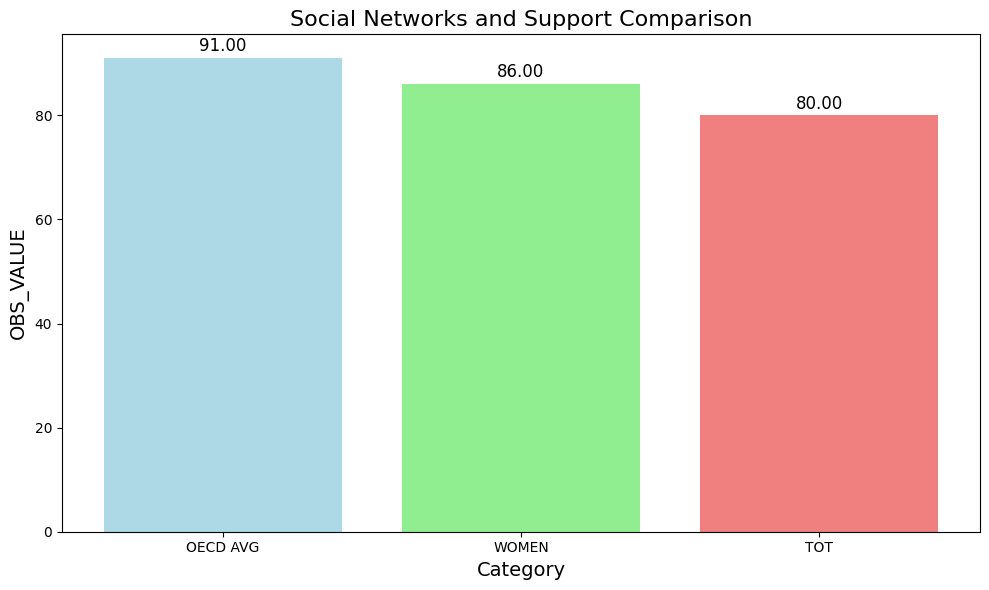

In [69]:
# 시각화
categories = ['OECD AVG', 'WOMEN', 'TOT']
values = [oecd_avg, female_value, total_value]

# 색상
colors = ['lightblue', 'lightgreen', 'lightcoral']

# 막대 그래프
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors)

# 각 막대 위에 값 표시
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x 위치
        bar.get_height() + 0.5,  # y 위치 (막대 위에 값 표시)
        f'{bar.get_height():.2f}',  # 표시할 값 (소수점 2자리)
        ha='center', va='bottom', fontsize=12
    )

# 제목 및 레이블 설정
plt.title("Social Networks and Support Comparison", fontsize=16)
plt.ylabel("OBS_VALUE", fontsize=14)
plt.xlabel("Category", fontsize=14)

# 그래프 출력
plt.tight_layout()
plt.show()

결과
  - 여성이 더 나은 사회적 네트워크를 가지고 있음
  - 하지만 전체적으로 OECD 평균에 못미치는 값을 가지고 있음

-> 전반적으로 사회적 네트워크를 강화하는 것이 필요 + 저소득층 및 남성의 사회적 고립을 해결하는 정책이 중요함

#### Top 10 과 비교

In [72]:
# TOT top 10
top_10 = sc_sntws_tot.sort_values(by="OBS_VALUE", ascending=False).head(10)

# 상위 10개 국가의 이름과 값
top_10_countries = top_10["Country"].values
top_10_values = top_10["OBS_VALUE"].values

print(top_10_countries,top_10_values)

['Iceland' 'Ireland' 'Finland' 'Norway' 'Czechia' 'Slovenia' 'Estonia'
 'New Zealand' 'Slovak Republic' 'Denmark'] [98. 96. 96. 96. 96. 95. 95. 95. 95. 95.]


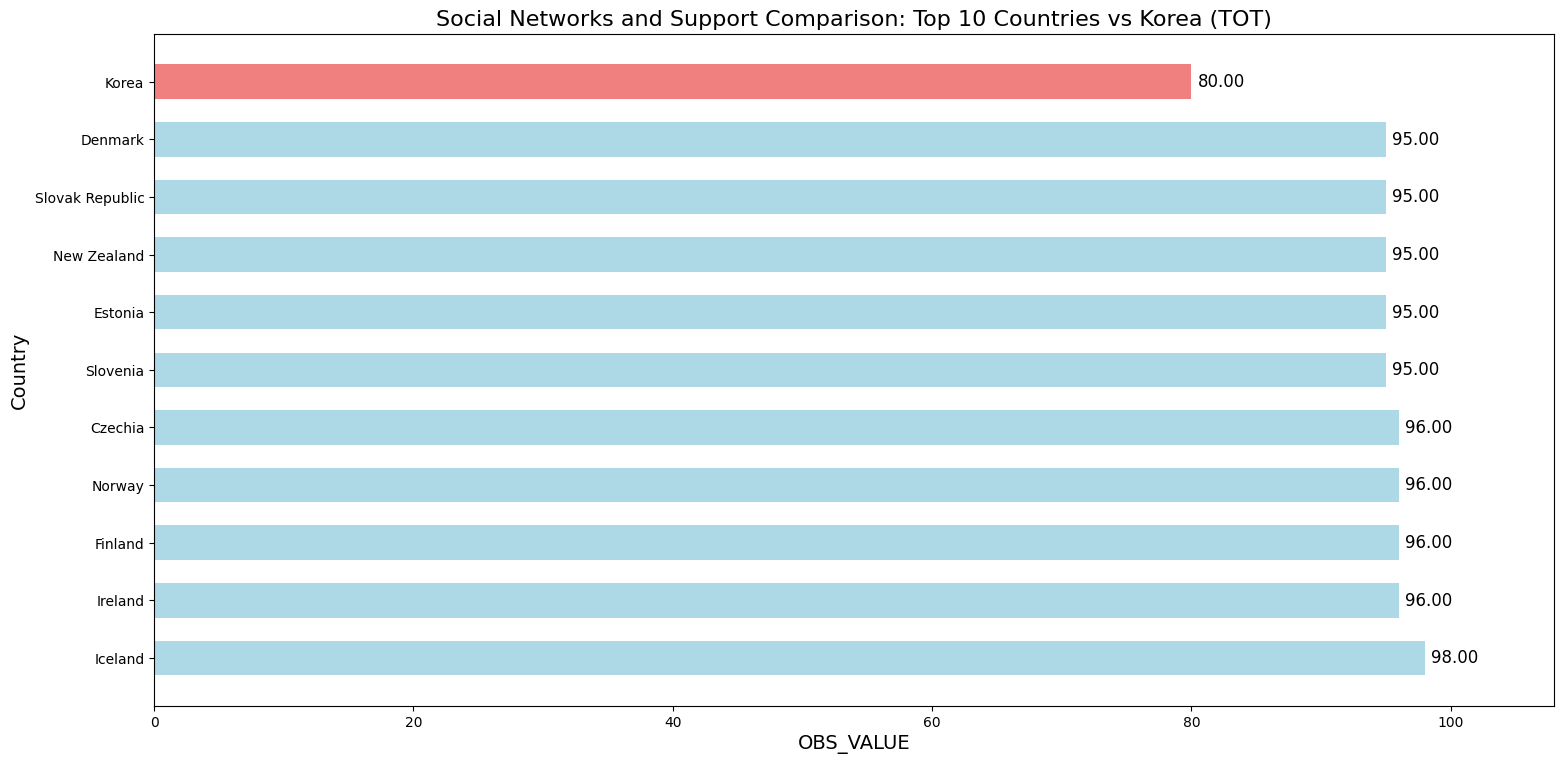

In [78]:
categories = list(top_10_countries) + ['Korea']
values = list(top_10_values) + [total_value]

# 색상 리스트 (Top 10 국가와 한국 전체 비교)
colors = ['lightblue'] * 10 + ['lightcoral']  # 한국은 다른 색으로 강조

# 그래프 크기
plt.figure(figsize=(16, 8))

# 막대 그래프 그리기
bars = plt.barh(categories, values, color=colors, height=0.6)  # height: 막대 간 간격 조정

# 각 막대 옆에 값 표시
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,  # x 위치 (막대 끝)
        bar.get_y() + bar.get_height() / 2,  # y 위치 (막대 중앙)
        f'{bar.get_width():.2f}',  # 표시할 값 (소수점 2자리)
        va='center', ha='left', fontsize=12
    )

# 제목 및 레이블 설정
plt.title("Social Networks and Support Comparison: Top 10 Countries vs Korea (TOT)", fontsize=16)
plt.xlabel("OBS_VALUE", fontsize=14)
plt.ylabel("Country", fontsize=14)

# x축의 범위 설정하여 여유 있게 만들기
plt.xlim(0, max(values) + 10)  # x축의 최대값에 여유 추가

# 그래프 레이아웃
plt.tight_layout(pad=2.0)  # pad : 여백추가

# 그래프 출력
plt.show()


행복지수 top20 국가들

In [84]:
df_top20 = df_avg.sort_values(by='happiness_score', ascending=False).head(20).reset_index(drop=True)
df_top20['country'].unique()

array(['Finland', 'Denmark', 'Switzerland', 'Iceland', 'Norway',
       'Netherlands', 'Sweden', 'New Zealand', 'Austria', 'Australia',
       'Canada', 'Luxembourg', 'Israel', 'United Kingdom', 'Ireland',
       'Germany', 'Costa Rica', 'United States', 'Belgium',
       'Czech Republic'], dtype=object)

위에서 **사회적 지원이 높**은데도 불구(Top10)하고 **행복지수 top20에 속하지 않는 나라**들 체크 <br>
    
      Slovenia, Estonia, Slovak Republic


In [87]:
countries = ['Slovenia', 'Estonia', 'Slovak Republic']

df_sorted = df_avg.sort_values(by='happiness_score', ascending=False).reset_index(drop=True)

for country in countries :
  if country in df_sorted['country'].values:
      rank = df_sorted[df_sorted['country'] == country].index[0] + 1  # 순위
      happiness_score = df_sorted[df_sorted['country'] == country]['happiness_score'].values[0]
      print(f"{country}: {happiness_score}, 순위: {rank}")
  else:
      print(f"{country}는 데이터프레임에 없습니다.")

Slovenia: 6.3040799964000005, 순위: 36
Estonia: 6.0367600082, 순위: 50
Slovak Republic는 데이터프레임에 없습니다.


➔  결과 : 우리나라 순위인 59위보다 높음.

**해결방안**<br>
1.경제적 지원 및 취약계층 보호

      저소득층과 기초생활보장 시스템의 취약점: 한국은 기초생활보장 제도를 운영하고 있지만, 저소득층에 대한 실질적 지원이 부족한 경우가 많습니다.
      일부 계층은 복지 혜택을 제대로 받지 못하고 있습니다.
      강화 방안: 기초생활수급자와 저소득층의 복지 혜택을 확충하고, 사회적 취약계층에게 실질적이고 지속적인 지원을 제공하는 제도를 강화해야 합니다.
      청년층 및 고령자 경제 지원: 특히 청년층과 고령층의 경제적 지원이 필요합니다. 청년실업과 고령층의 경제적 자립이 중요한 문제입니다.
      강화 방안: 청년층 직업 훈련 및 취업 지원 프로그램과 고령자 일자리 창출 및 연금 제도 개선이 필요합니다.

2.사회적 지원 네트워크

      사회적 연대 부족: 한국은 개인주의적인 성향이 강해 사회적 연대나 공동체 의식이 상대적으로 부족할 수 있습니다.
      이는 특히 저소득층, 고립된 노인, 청소년에게 더 큰 영향을 미칩니다.
      강화 방안: 자원봉사 활성화와 사회적 기업 지원을 통해 사회적 네트워크를 활성화하고, 사회적 지원 시스템을 지역사회에서 강화해야 합니다.

### Freedom to Make Life Choices(삶의 선택 자유)

#### 여가 및 개인시간(WL_TNOW)

In [15]:
wl_tnow = worklifebalance[worklifebalance['INDICATOR']=='WL_TNOW']

In [17]:
wl_tnow = wl_tnow.sort_values(by="OBS_VALUE", ascending=False)
wl_tnow
# 순위
rank = wl_tnow.reset_index().index[wl_tnow["Country"] == "Korea"][0] + 1

# 출력
print(f"나라 수: {wl_tnow.shape[0]}")
print(f"한국의 여가 및 개인시간 순위: {rank}")

나라 수: 69
한국의 삶의 만족도 순위: 27


#### 초과 근무시간(WL_EWLH)

In [19]:
wl_ewlh = worklifebalance[worklifebalance['INDICATOR']=='WL_EWLH']

In [24]:
wl_ewlh = wl_ewlh.sort_values(by="OBS_VALUE", ascending=False)
# # 순위
# rank = wl_ewlh.reset_index().index[wl_ewlh["Country"] == "Korea"][0] + 1

# # 출력
# print(f"나라 수: {wl_ewlh.shape[0]}")
# print(f"한국의 여가 및 개인시간 순위: {rank}")

Korea가 포함이 안되어있음

#### 투표율(CG_VOTO)

In [26]:
cg_voto = worklifebalance[worklifebalance['INDICATOR']=='CG_VOTO']

In [28]:
cg_voto = cg_voto.sort_values(by="OBS_VALUE", ascending=False)
# 순위
rank = cg_voto.reset_index().index[cg_voto["Country"] == "Korea"][0] + 1

# 출력
print(f"나라 수: {wl_ewlh.shape[0]}")
print(f"한국의 투표율: {rank}")

나라 수: 120
한국의 투표율: 12


WL_TNOW(여가 및 개인시간), WL_EWLH(초과 근무시간):데이터 없음, CG_VOTO(투표율) 모두 높은 순위를 기록하고 있는데 왜 자유도가 낮을까?<br>
➔ 경제적 자유 & 소득 격차 <br>
➔ 사회적 자유 & 시민 참여 <br>
➔ 노동 & 삶의 균형 <br>
➔ 기본적 권리 & 안전 <br>

OECD 삶의 만족도 (SW_LIFS) 한번 보기

In [38]:
sw_lifs= worklifebalance[worklifebalance['INDICATOR']=='SW_LIFS']
sw_lifs= sw_lifs.sort_values(by='OBS_VALUE', ascending=False)

In [40]:
# 순위
rank = wl_tnow.reset_index().index[wl_tnow["Country"] == "Korea"][0] + 1

# 출력
print(f"나라 수: {wl_tnow.shape[0]}")
print(f"삶의 만족도: {rank}")

나라 수: 69
삶의 만족도: 27


좀 더 우리나라 happiness score을 2018-2022말고 2024까지 확장시켜보기로함.<br> **(mid/3.19)행복지수2023/2024data.ipynb 파일 보기**

#### 경제적인 자유

먼저 위에서 노동시장안정성(je_lms)을 봤을 때 노동시장은 안정적

In [ ]:
#JE_EMPL: 고용률 (Employment rate)
#JE_LTUR: 장기 실업률 (Long-term unemployment rate)
#JE_PEARN: 평균 소득 (Personal earnings)